In [282]:
#importing libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [283]:
#importing datasets 
df1 = pd.read_csv('cleaned_social_media_dataset.csv')
df2 = pd.read_csv('filtered_social_media_engagement.csv')
df3 = pd.read_csv('Filtered_Social_Media_Sentiment.csv')

In [284]:
#first five volumns of the datasets

print("First five rows of df1:")
df1.head()




First five rows of df1:


,platform,creator_id,creator_name,content_category,post_date,language,views,likes,shares,comments_count,follower_count,is_sponsored,audience_location,is_tech
0,youtube,creator_1502,derek94,tech,5/30/23 11:26 PM,English,9925,1491,320,215,929015,False,India,True
1,youtube,creator_2976,lukeburton,tech,5/31/23 7:49 AM,English,10031,1567,285,206,272307,True,Japan,True
2,tiktok,creator_1044,hwelch,tech,5/31/23 9:22 AM,Chinese,10049,1495,284,193,48334,True,India,True
3,tiktok,creator_3818,jennifer05,tech,6/1/23 8:00 PM,English,10114,1563,268,206,918976,True,Japan,True
4,tiktok,creator_4604,trevor43,tech,6/2/23 2:46 AM,English,10210,1501,314,214,501327,True,China,True


In [285]:
print("\nFirst five rows of df2:")
df2.head()




First five rows of df2:


,platform,user_id,location,hashtags,likes_count,shares_count,comments_count,impressions,engagement_rate,brand_name,user_engagement_growth,buzz_change_rate,is_tech
0,facebook,user_snl52zoj,uae,"#Tech, #Reviews",1994,426,313,48947,0.05583,Google,0.3286,23.2,True
1,twitter,user_3kwb0q9d,uae,"#Food, #Sustainable",567,667,645,87728,0.02141,Toyota,0.0365,-46.6,True
2,youtube,user_0wsgo6ge,uae,"#Tech, #NewRelease",1112,279,522,98131,0.01949,Samsung,0.2643,-63.6,True
3,youtube,user_dc66dcss,uae,"#Travel, #Fitness, #Innovation",1460,614,189,5152,0.43924,Nike,0.3049,-39.3,True
4,facebook,user_4qb32son,uae,"#Limited, #Promo, #Innovation",3282,179,438,16437,0.23720,Coca-Cola,-0.4202,2.7,True


In [286]:
print("\nFirst five rows of df3:")
df3.head()


First five rows of df3:


,platform,username,user_followers_count,user_location,hashtags,like_count,comment_count,share_count,engagement_score,is_tech
0,youtube,skrjxlgb,308453,pakistan,"#trending,#ai",1929,1875,276,0.91,True
1,twitter,krvzmanp,458337,india,"#trending,#ai",4723,3358,2681,0.97,True
2,twitter,xdlggaux,38734,india,"#trending,#ai",13903,2048,1871,0.85,True
3,youtube,lkcwtfub,278199,pakistan,"#trending,#ai",4839,1935,421,0.15,True
4,twitter,hulklyie,192605,pakistan,"#trending,#ai",2586,3527,2467,1.00,True


# Data Cleaning and Handling 





In [287]:
common_cols = [
    'platform',
    'creator',
    'content_category',
    'views',
    'likes',
    'shares',
    'comments',
    'followers',
    'location',
    'engagement_rate',
    'is_tech'
]

In [288]:
#df1 

df1.drop(columns = ['creator_id', 'post_date', 'language', 'is_sponsored'], inplace = True)

df1 = df1.rename(columns={
    'creator_name': 'creator',
    'comments_count': 'comments',
    'follower_count': 'followers',
    'audience_location': 'location'
})

# engagement rate formula
df1['engagement_rate'] = (
    (df1['likes'] + df1['shares'] + df1['comments']) / df1['views']
)

df1['content_category'] = df1['content_category']  

df1 = df1[common_cols]

In [289]:
df1.columns

Index(['platform', 'creator', 'content_category', 'views', 'likes', 'shares',
       'comments', 'followers', 'location', 'engagement_rate', 'is_tech'],
      dtype='object')

In [290]:
#df2 
df2 = df2.rename(columns={
    'user_id': 'creator',
    'likes_count': 'likes',
    'shares_count': 'shares',
    'comments_count': 'comments',
    'impressions': 'views',
    'location': 'location'
    
})

df2 = df2.rename(columns = {'hashtags': 'content_category'})








In [291]:
df2.columns

Index(['platform', 'creator', 'location', 'content_category', 'likes',
       'shares', 'comments', 'views', 'engagement_rate', 'brand_name',
       'user_engagement_growth', 'buzz_change_rate', 'is_tech'],
      dtype='object')

In [292]:
#df3
df3 = df3.rename(columns={
    'username': 'creator',
    'user_followers_count': 'followers',
    'user_location': 'location',
    'like_count': 'likes',
    'comment_count': 'comments',
    'share_count': 'shares'
    
})

df3 = df3.rename(columns = {'hashtags': 'content_category'})




In [293]:
df3.columns 

Index(['platform', 'creator', 'followers', 'location', 'content_category',
       'likes', 'comments', 'shares', 'engagement_score', 'is_tech'],
      dtype='object')

In [294]:
#merge all the datasets
df = pd.concat([df1, df2, df3], ignore_index=True)

In [295]:
df.head()

,platform,creator,content_category,views,likes,shares,comments,followers,location,engagement_rate,is_tech,brand_name,user_engagement_growth,buzz_change_rate,engagement_score
0,youtube,derek94,tech,9925.0,1491,320,215,929015.0,India,0.204131,True,NaN,NaN,NaN,NaN
1,youtube,lukeburton,tech,10031.0,1567,285,206,272307.0,Japan,0.205164,True,NaN,NaN,NaN,NaN
2,tiktok,hwelch,tech,10049.0,1495,284,193,48334.0,India,0.196238,True,NaN,NaN,NaN,NaN
3,tiktok,jennifer05,tech,10114.0,1563,268,206,918976.0,Japan,0.201404,True,NaN,NaN,NaN,NaN
4,tiktok,trevor43,tech,10210.0,1501,314,214,501327.0,China,0.198727,True,NaN,NaN,NaN,NaN


In [296]:
df.isna().sum()

platform                    0
creator                     0
content_category            0
views                     209
likes                       0
shares                      0
comments                    0
followers                  11
location                    0
engagement_rate           209
is_tech                     0
brand_name                259
user_engagement_growth    259
buzz_change_rate          259
engagement_score           61
dtype: int64

# Feature Engineering 

In [297]:
# Reach Efficiency 
df['reach_efficiency'] = df['views'] / df['followers']


#Vira;ity Score 
df['virality_score'] = (df['likes'] + df['shares'] + df['comments']) / df['followers']


#Interaction depth
df['interaction_rate'] = df['comments'] / df['views']

In [298]:
#final influencer score 

#custom weights for each metric
#reach_efficiency= 0.3
#engagement_rate = 0.4
#virality_score = 0.3


df['influencer_score'] = (
    0.4 * df['engagement_rate'] +
    0.3 * df['reach_efficiency'] +
    0.3 * df['virality_score']
)

In [299]:
df.sort_values('influencer_score', ascending=False)[
    ['creator', 'platform', 'influencer_score']
].head(10)

,creator,platform,influencer_score
5,rodriguezjennifer,tiktok,1.905219
2,hwelch,tiktok,0.153107
21,samuelsmith,tiktok,0.137101
44,timothytaylor,youtube,0.119227
31,reneelopez,youtube,0.102322
33,angel79,youtube,0.097052
1,lukeburton,youtube,0.095384
15,wademadison,tiktok,0.095002
20,bhayes,youtube,0.093611
41,hclark,tiktok,0.090862


In [300]:
df.groupby('platform')[[
    'engagement_rate',
    'virality_score',
    'influencer_score'
]].mean()

,engagement_rate,virality_score,influencer_score
platform,,,
facebook,0.100597,NaN,NaN
instagram,0.043590,NaN,NaN
tiktok,0.200494,0.053450,0.174774
twitter,0.075490,0.257124,NaN
youtube,0.201080,0.070330,0.088110


In [301]:
df.groupby('location')[[
    'engagement_rate',
    'influencer_score'
]].mean().sort_values(by='influencer_score', ascending=False)

,engagement_rate,influencer_score
location,,
Japan,0.200019,0.180750
India,0.199471,0.093679
China,0.199471,0.087016
india,NaN,NaN
pakistan,NaN,NaN
uae,0.109697,NaN


In [302]:
#handle null values 
df.isnull().sum()


platform                    0
creator                     0
content_category            0
views                     209
likes                       0
shares                      0
comments                    0
followers                  11
location                    0
engagement_rate           209
is_tech                     0
brand_name                259
user_engagement_growth    259
buzz_change_rate          259
engagement_score           61
reach_efficiency          220
virality_score             11
interaction_rate          209
influencer_score          220
dtype: int64

In [303]:
(df.isnull().mean() * 100).sort_values(ascending=False)

brand_name                95.925926
buzz_change_rate          95.925926
user_engagement_growth    95.925926
influencer_score          81.481481
reach_efficiency          81.481481
interaction_rate          77.407407
views                     77.407407
engagement_rate           77.407407
engagement_score          22.592593
virality_score             4.074074
followers                  4.074074
content_category           0.000000
creator                    0.000000
platform                   0.000000
is_tech                    0.000000
likes                      0.000000
location                   0.000000
shares                     0.000000
comments                   0.000000
dtype: float64

In [304]:
#Implying Handling Strategy 

#For numerical columns median - skewed data
num_cols = ['views','likes','shares','comments','followers',
            'engagement_rate','reach_efficiency','virality_score', 'interaction_rate', 'user_engagement_growth', 'buzz_change_rate',
            'engagement_score']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())  #influencer data is highly skewed

#For Categorical columns Unknown 
cat_cols = ['platform','creator','location','content_category', 'brand_name']

df[cat_cols] = df[cat_cols].fillna('Unknown')

In [305]:
#fill engagement rate by platform 

df['engagement_rate'] = df['engagement_rate'].fillna(
    df.groupby('platform')['engagement_rate'].transform('median')
)

In [306]:
#Recalculate feature engineering 

df['engagement_rate'] = (
    (df['likes'] + df['comments'] + df['shares']) / df['views']
)

df['reach_efficiency'] = df['views'] / df['followers']

df['virality_score'] = df['shares'] / df['views']



In [307]:
#Recompute influencer score after handling 
df['influencer_score'] = (
    0.4 * df['engagement_rate'] +
    0.3 * df['reach_efficiency'] +
    0.3 * df['virality_score']
)

In [308]:
#final check 
df.describe()


,views,likes,shares,comments,followers,engagement_rate,user_engagement_growth,buzz_change_rate,engagement_score,reach_efficiency,virality_score,interaction_rate,influencer_score
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,11875.581481,8229.622222,1273.500000,2015.911111,315005.011111,1.130583,0.143716,2.942593,0.504296,0.125744,0.123915,0.019401,0.527131
std,10516.144083,6452.984294,922.184076,1577.427884,209715.503876,0.751129,0.052176,10.448130,0.251137,0.436397,0.092263,0.002378,0.337132
min,5152.000000,64.000000,8.000000,24.000000,2003.000000,0.019494,-0.420200,-65.900000,0.000000,0.010173,0.000791,0.002714,0.068662
25%,10120.000000,1571.500000,317.750000,311.500000,154221.000000,0.408399,0.144600,2.900000,0.342500,0.024350,0.030814,0.019499,0.219109
50%,10120.000000,7000.000000,1180.000000,1733.500000,308441.000000,1.097233,0.144600,2.900000,0.520000,0.034605,0.112451,0.019499,0.515451
75%,10120.000000,14352.750000,2108.250000,3518.000000,413978.250000,1.759906,0.144600,2.900000,0.680000,0.077004,0.208325,0.019499,0.799846
max,99487.000000,19977.000000,2959.000000,4980.000000,984343.000000,2.603854,0.459200,91.200000,1.000000,5.043435,0.292391,0.036685,1.604656


In [309]:
df.isnull().sum()

platform                  0
creator                   0
content_category          0
views                     0
likes                     0
shares                    0
comments                  0
followers                 0
location                  0
engagement_rate           0
is_tech                   0
brand_name                0
user_engagement_growth    0
buzz_change_rate          0
engagement_score          0
reach_efficiency          0
virality_score            0
interaction_rate          0
influencer_score          0
dtype: int64

# Visualization 


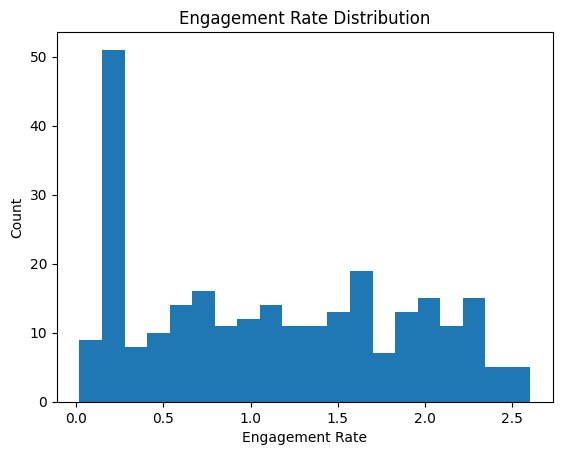

In [311]:
# Engagement Rate Distribution


plt.figure()
plt.hist(df['engagement_rate'].dropna(), bins=20)
plt.title("Engagement Rate Distribution")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")
plt.show()

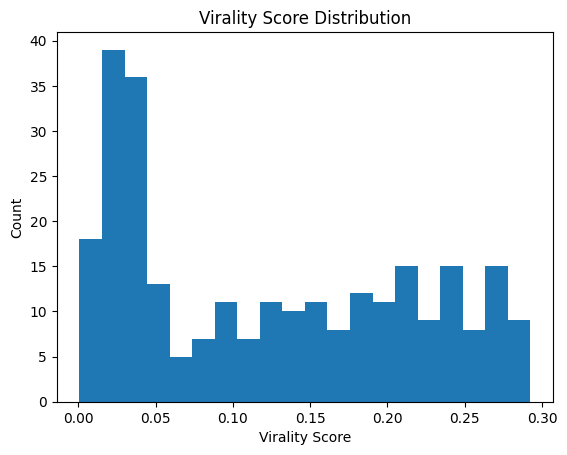

In [313]:
# Virality Score Distribution
plt.figure()
plt.hist(df['virality_score'].dropna(), bins=20)
plt.title("Virality Score Distribution")
plt.xlabel("Virality Score")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

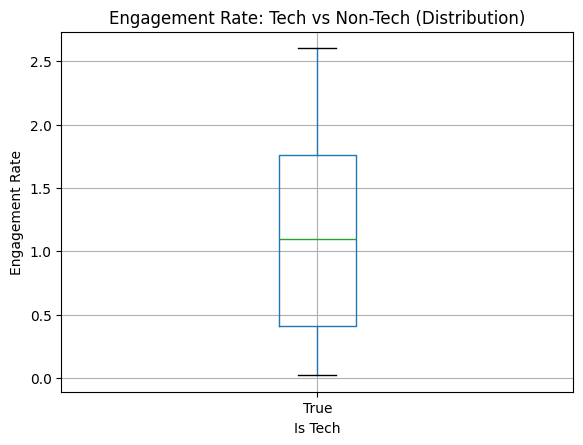

In [315]:
#Engagement in Tech vs Non-Tech


plt.figure()
df.boxplot(column='engagement_rate', by='is_tech')
plt.title("Engagement Rate: Tech vs Non-Tech (Distribution)")
plt.suptitle("")  # removes default subtitle
plt.xlabel("Is Tech")
plt.ylabel("Engagement Rate")
plt.show()


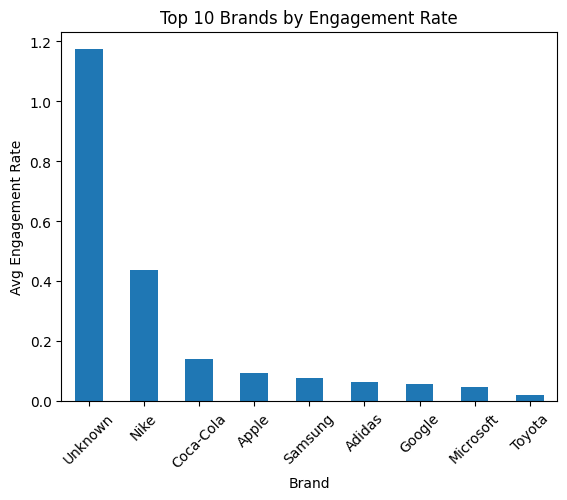

In [320]:
# Brand-WIse Engagement 
if 'brand_name' in df.columns:
    brand_data = df.groupby('brand_name')['engagement_rate'].mean().sort_values(ascending=False).head(10)

    plt.figure()
    brand_data.plot(kind='bar')
    plt.title("Top 10 Brands by Engagement Rate")
    plt.xlabel("Brand")
    plt.ylabel("Avg Engagement Rate")
    plt.xticks(rotation=45)
    plt.show()

In [321]:
df.to_csv('tech_influencers(asian)_cleaned.csv', index=False)

In [322]:
df.columns

Index(['platform', 'creator', 'content_category', 'views', 'likes', 'shares',
       'comments', 'followers', 'location', 'engagement_rate', 'is_tech',
       'brand_name', 'user_engagement_growth', 'buzz_change_rate',
       'engagement_score', 'reach_efficiency', 'virality_score',
       'interaction_rate', 'influencer_score'],
      dtype='object')

In [323]:
df.head()

,platform,creator,content_category,views,likes,shares,comments,followers,location,engagement_rate,is_tech,brand_name,user_engagement_growth,buzz_change_rate,engagement_score,reach_efficiency,virality_score,interaction_rate,influencer_score
0,youtube,derek94,tech,9925.0,1491,320,215,929015.0,India,0.204131,True,Unknown,0.1446,2.9,0.52,0.010683,0.032242,0.021662,0.094530
1,youtube,lukeburton,tech,10031.0,1567,285,206,272307.0,Japan,0.205164,True,Unknown,0.1446,2.9,0.52,0.036837,0.028412,0.020536,0.101640
2,tiktok,hwelch,tech,10049.0,1495,284,193,48334.0,India,0.196238,True,Unknown,0.1446,2.9,0.52,0.207907,0.028262,0.019206,0.149346
3,tiktok,jennifer05,tech,10114.0,1563,268,206,918976.0,Japan,0.201404,True,Unknown,0.1446,2.9,0.52,0.011006,0.026498,0.020368,0.091813
4,tiktok,trevor43,tech,10210.0,1501,314,214,501327.0,China,0.198727,True,Unknown,0.1446,2.9,0.52,0.020366,0.030754,0.020960,0.094827
